In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 18359, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 18359 (delta 38), reused 22 (delta 16), pack-reused 18276 (from 2)
Receiving objects: 100% (18359/18359), 17.54 MiB | 15.16 MiB/s, done.
Resolving deltas: 100% (12463/12463), done.
/content/yolov5/yolov5


In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.1 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')

from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("2026-oss").project("ai-picture-book-object-detection")
dataset = project.version(2).download("yolov5")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov5pytorch in progress : 0.1%
Version export complete for yolov5pytorch format



Extracting Dataset Version Zip to AI-Picture-Book-Object-Detection-2 in yolov5pytorch:: 100%|██████████| 1445/1445 [00:00<00:00, 8839.19it/s]


In [ ]:
!ls

AI-Picture-Book-Object-Detection-2  export.py	     requirements.txt
benchmarks.py			    hubconf.py	     segment
CITATION.cff			    LICENSE	     tests
classify			    models	     train.py
CONTRIBUTING.md			    pyproject.toml   tutorial.ipynb
data				    README.md	     utils
detect.py			    README.zh-CN.md  val.py


In [ ]:
!find . -name "data.yaml"

./AI-Picture-Book-Object-Detection-2/data.yaml


In [ ]:
yaml_path = "./AI-Picture-Book-Object-Detection-2/data.yaml"

with open(yaml_path, "r") as f:
    data = f.read()

data = data.replace("train: ../train/images", "train: ./AI-Picture-Book-Object-Detection-2/train/images")
data = data.replace("val: ../valid/images", "val: ./AI-Picture-Book-Object-Detection-2/valid/images")
data = data.replace("test: ../test/images", "test: ./AI-Picture-Book-Object-Detection-2/test/images")

with open(yaml_path, "w") as f:
    f.write(data)

!cat ./AI-Picture-Book-Object-Detection-2/data.yaml

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!nvidia-smi

Sat Jun 13 13:50:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!wget https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt

--2026-06-13 13:50:30--  https://github.com/ultralytics/yolov5/releases/download/v7.0/yolov5s.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/264818686/381bd8a8-8910-4e9e-b0dd-2752951ef78c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-13T14%3A36%3A16Z&rscd=attachment%3B+filename%3Dyolov5s.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-06-13T13%3A35%3A59Z&ske=2026-06-13T14%3A36%3A16Z&sks=b&skv=2018-11-09&sig=WrlKs6rUs8aVkaSzaR%2FjjS2r%2FOVGFSlJ9Qh23YxYTJ8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4MTM2MDQzMCwibmJmIjoxNzgxMzU4NjMwLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdGlvbi5ibG9iLmN

In [ ]:
!python train.py \
--img 640 \
--batch 16 \
--epochs 100 \
--data ./AI-Picture-Book-Object-Detection-2/data.yaml \
--weights yolov5s.pt \
--name picture_book_yolov5

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
      41/99       4.5G    0.03287    0.01232   0.003427         40        640:  38% 15/40 [00:05<00:11,  2.23it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/99       4.5G    0.03332    0.01234   0.003546         32        640:  40% 16/40 [00:06<00:12,  1.85it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/99       4.5G    0.03345    0.01221   0.003498         32        640:  42% 17/40 [00:06<00:10,  2.18it/s]/content/yolov5/yolov5/train.py:414: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(amp):
      41/99       4.5G    0.033

In [ ]:
!ls runs/train

exp


In [ ]:
!python detect.py \
--weights runs/train/exp/weights/best.pt \
--conf 0.25 \
--source ./AI-Picture-Book-Object-Detection-2/test/images

detect: weights=['runs/train/exp/weights/best.pt'], source=./AI-Picture-Book-Object-Detection-2/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7026307 parameters, 0 gradients, 15.8 GFLOPs
image 1/30 /content/yolov5/yolov5/AI-Picture-Book-Object-Detection-2/test/images/book_flowerpot_0001_jpeg.rf.bd70f4fbdee01021e3ae1d7a7ecc9374.jpg: 640x640 1 book_flowerpot, 11.4ms
image 2/30 /content/yolov5/yolov5/AI-Picture-Book-Object-Detection-2/test/images/book_flowerpot_0009_jpe

Best weights: runs/train/exp/weights/best.pt
detect: weights=['runs/train/exp/weights/best.pt'], source=./AI-Picture-Book-Object-Detection-2/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7026307 parameters, 0 gradients, 15.8 GFLOPs
image 1/30 /content/yolov5/yolov5/AI-Picture-Book-Object-Detection-2/test/images/book_flowerpot_0001_jpeg.rf.bd70f4fbdee01021e3ae1d7a7ecc9374.jpg: 640x640 1 book_flowerpot, 11.4ms
image 2/30 /content/yolov5/yolov5/AI-Picture-Book-Object-De

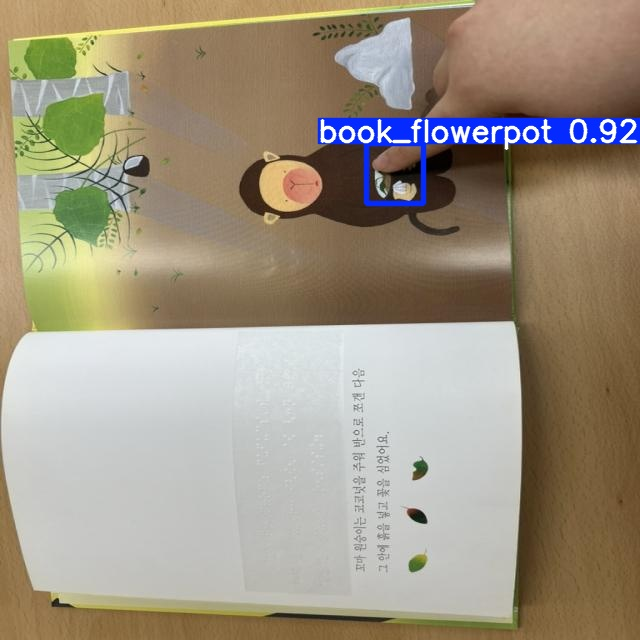

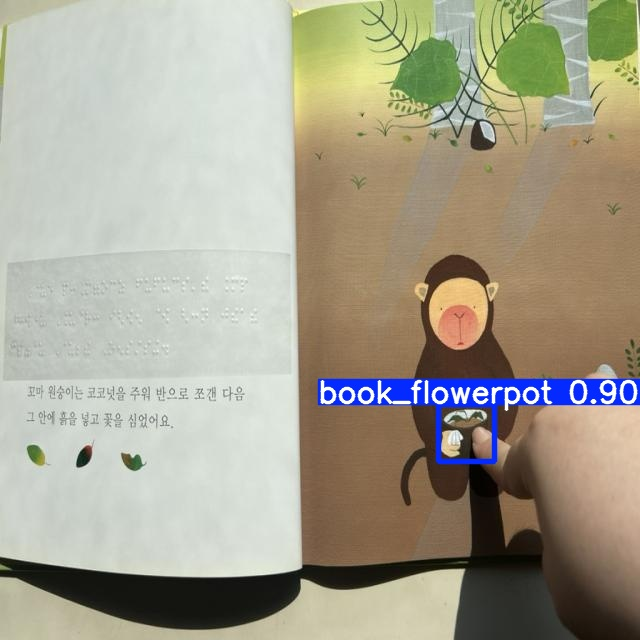

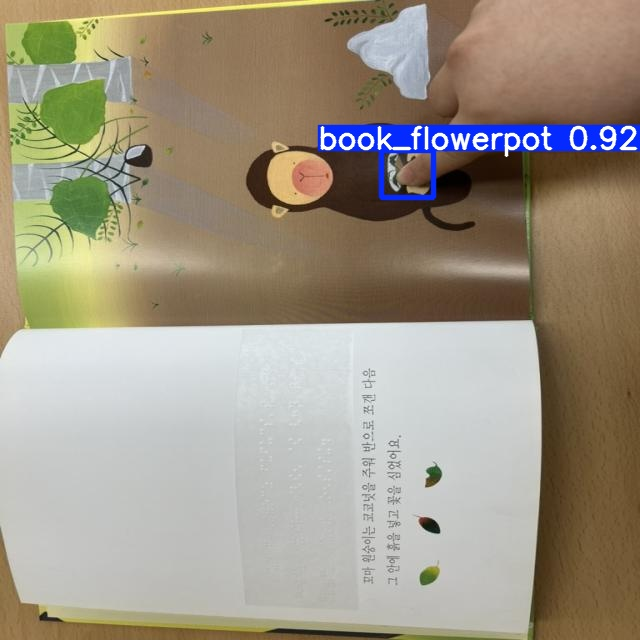

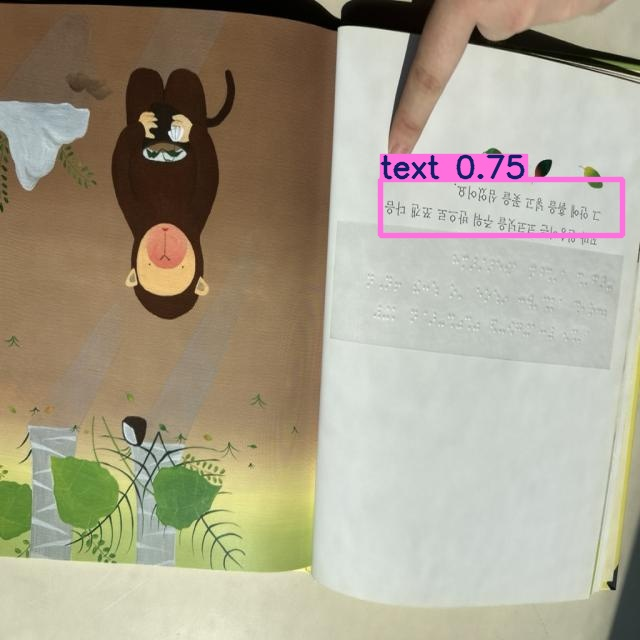

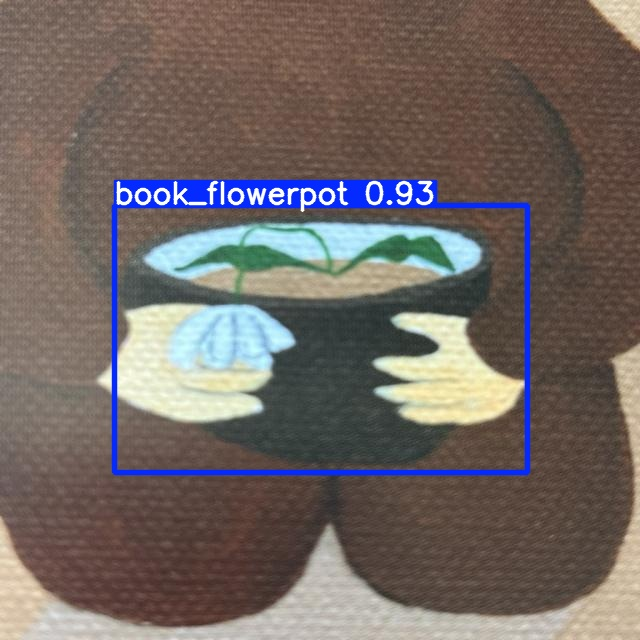

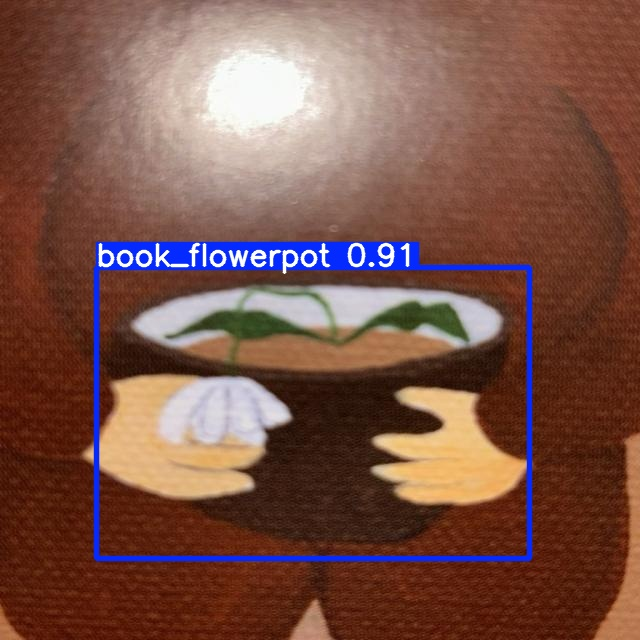

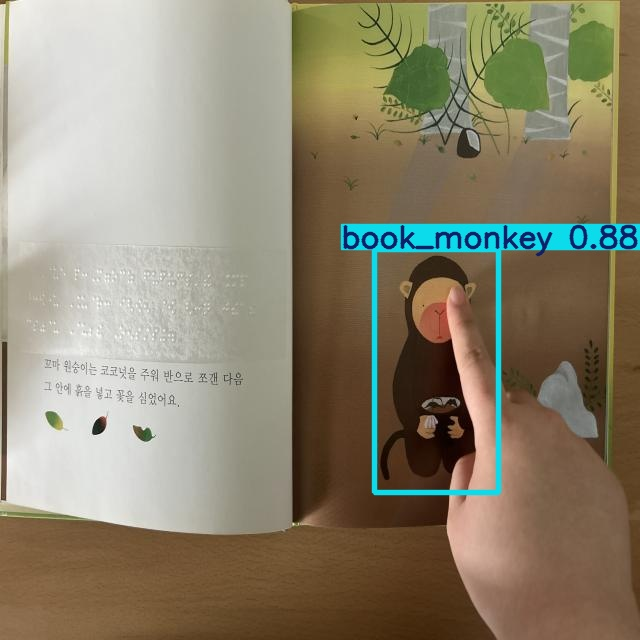

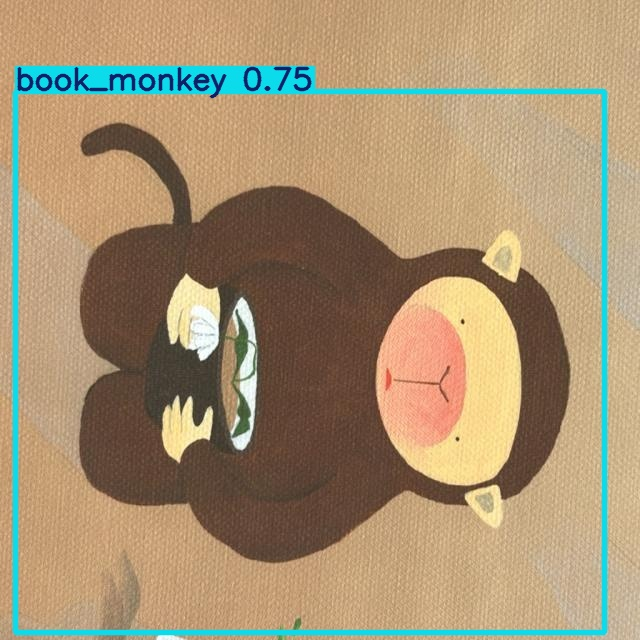

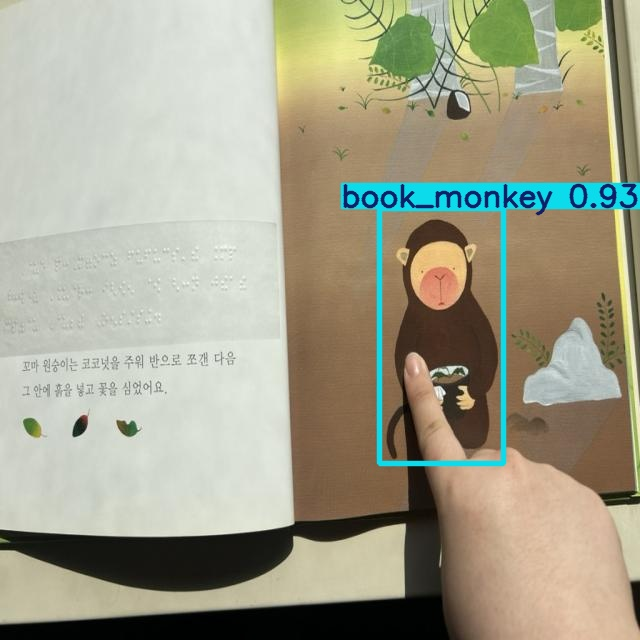

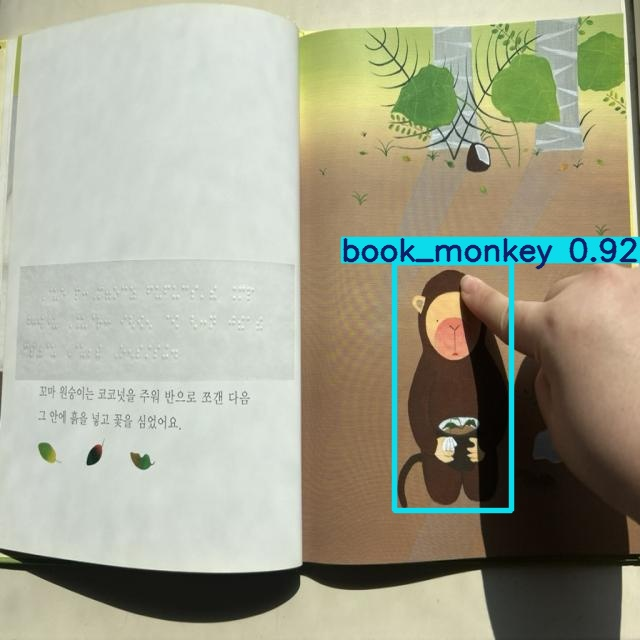

val: data=./AI-Picture-Book-Object-Detection-2/data.yaml, weights=['runs/train/exp/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-503-gb8493964 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7026307 parameters, 0 gradients, 15.8 GFLOPs
Traceback (most recent call last):
  File "/content/yolov5/yolov5/utils/dataloaders.py", line 579, in __init__
    raise FileNotFoundError(f"{prefix}{p} does not exist")
FileNotFoundError: test: /content/yolov5/yolov5/test/images does not exist

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/content/yolov5/yolov5/val.py", line 527, in <module>
    main(opt)
  Fi

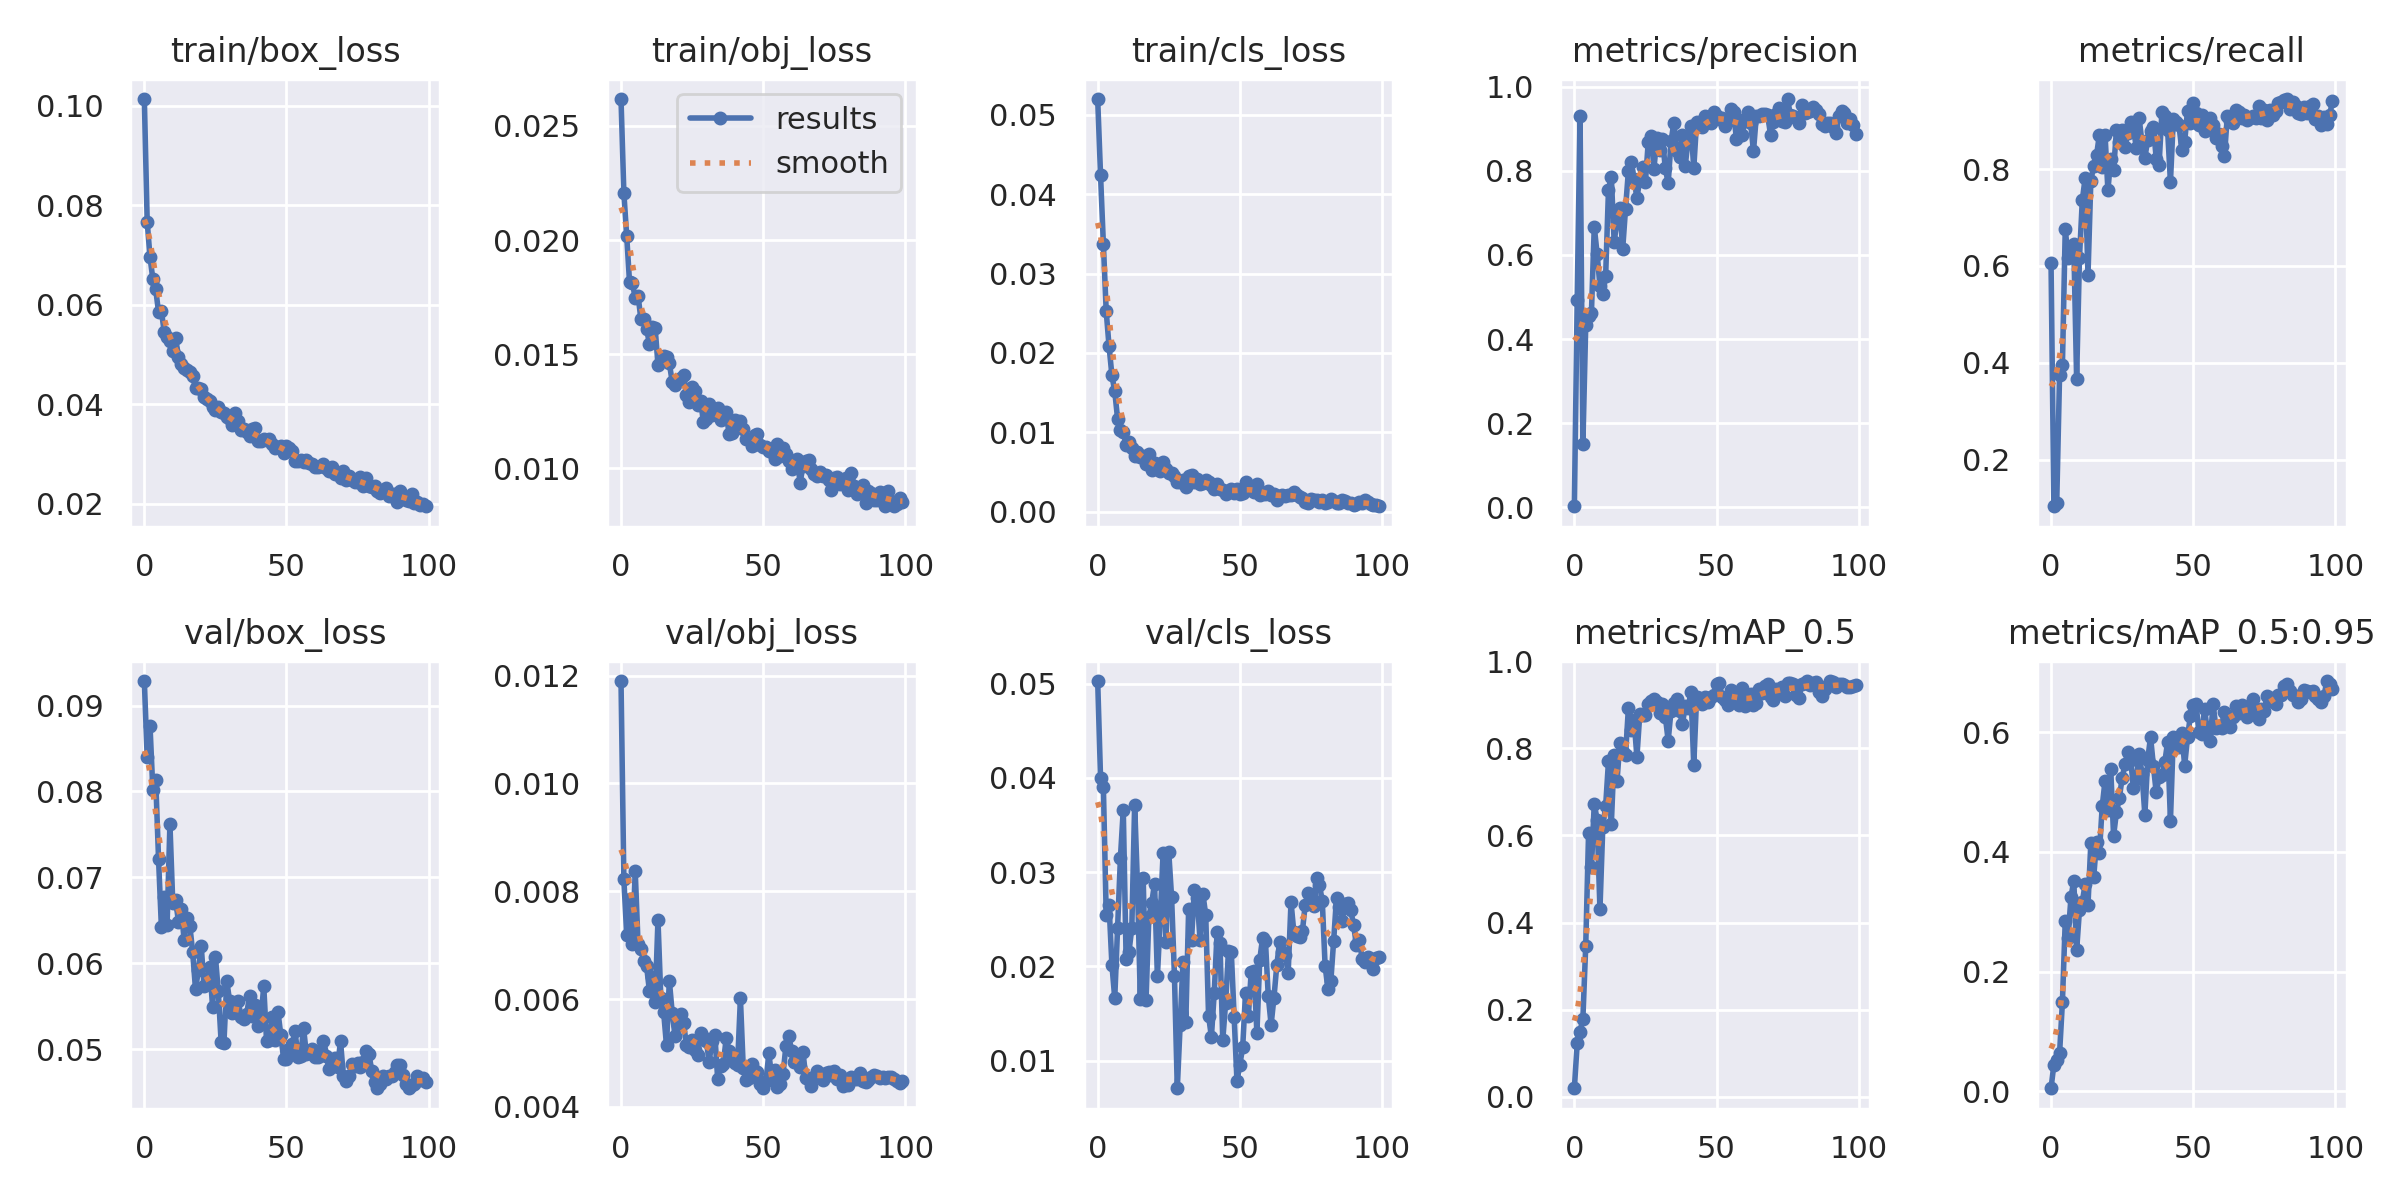

In [ ]:
import glob

best_weights = sorted(glob.glob("runs/train/exp*/weights/best.pt"))[-1]
print("Best weights:", best_weights)

!python detect.py \
--weights {best_weights} \
--conf 0.25 \
--source ./AI-Picture-Book-Object-Detection-2/test/images

from IPython.display import Image, display

results = sorted(glob.glob("runs/detect/exp*/*.jpg"))

for img in results[:10]:
    display(Image(filename=img))

!python val.py \
--weights {best_weights} \
--data ./AI-Picture-Book-Object-Detection-2/data.yaml \
--img 640 \
--task test

result_img = sorted(glob.glob("runs/train/exp*/results.png"))[-1]
display(Image(filename=result_img))